# Section 4.4 - Time-domain eigenvalue calculation

## Setup of System Matrix
Again, we need to assemble the system matrix, which is a combination of the spatial operator (i.e., Laplace) and the time-stepping.

Notice a few differences to before
- We include the boundary elements
- We use a sparse matrix here (otherwise, we have $\mathcal O(nx^2)$ complexity in terms of memory consumption and in terms of time due the costs of a single matrix-vector product.

In [9]:
using SparseArrays # Package needed for sparse matrix linear algebra

"""
    Wave1D_Dirichlet(a, nx, dt, dx::F=a/nx)

Discretizes the Wave-Operator for a problem of length `a` 
with homogeneous Dirichlet BC using `nx` segments and incorporating time step `dt`.
"""
function Wave1D_Dirichlet(a::F, nx::I, dt::F, dx::F=a/nx) where {F, I}

    # If the user passes dx, ensure that it is compatible.
    @assert dx == a/nx
    
    @assert dt < dx # ensure CFL condition with c=1

    # Build the L-operator
    d = 2*(1-(dt/dx)^2)
    s = (dt/dx)^2
    
    # This time we build a sparse matrix
    # We use the coordinate format storing
    # row and column index as well as the element
    # separately
    A_row = zeros(I, 3*nx-5)
    A_col = zeros(I, 3*nx-5)
    A_elem = zeros(F, 3*nx-5)

    for i=1:nx-1
        A_row[i] = i+1
        A_col[i] = i+1
        A_elem[i] = d
    end

    for i=1:nx-2
        A_row[nx - 1 + 2*i-1] = i+2
        A_col[nx - 1 + 2*i-1] = i+1
        A_elem[nx - 1 + 2*i-1] = s
        A_row[nx - 1 + 2*i] = i+1
        A_col[nx - 1 + 2*i] = i+2
        A_elem[nx - 1 + 2*i] = s
    end

    A = sparse(A_row, A_col, A_elem, nx+1, nx+1)
end

Wave1D_Dirichlet

In [16]:
Wave1D_Dirichlet(1.0, 5, 0.01) |> Matrix
# Meaning of the operator |>
# We could likewise write 
# Matrix(Wave1D_Dirichlet(1.0, 5, 0.01))
# The nesting of function can become difficult to read
# so using |> might improve clarity 

6×6 Matrix{Float64}:
 0.0  0.0     0.0     0.0     0.0     0.0
 0.0  1.995   0.0025  0.0     0.0     0.0
 0.0  0.0025  1.995   0.0025  0.0     0.0
 0.0  0.0     0.0025  1.995   0.0025  0.0
 0.0  0.0     0.0     0.0025  1.995   0.0
 0.0  0.0     0.0     0.0     0.0     0.0

Notice the inclusion of the boundary elements: by setting the left and the right most column to zero, we enforce the homogeneous Dirichlet BCs.

In [17]:
using FFTW

"""
    Wave1D(a, time, nx)

Runs a leap-frogged based time simulation of the 1-D wave equation (problem of length `a`) 
with homogeneous Dirichlet BC using `nx` segments and simulate for time `time`
with a random initial

"""
function Wave1D(a::F, time::F, nx::I) where {F, I}

    # Signal at t=0
    f0 = rand(F, nx+1)
    f0[1] = 0 # Dirichlet BCs must be satisfied 
    f0[end] = 0 # Dirichlet BCs must be satisfied

    # Signal at t=Δt (Signal after first time step)
    f1 = rand(F, nx+1)
    f1[1] = 0 # Dirichlet BCs must be satisfied
    f1[end] = 0 # Dirichlet BCs must be satisfied

    dx = a/nx # The cell size
    d2tmax = 1.9*dx # The time step must satisfy 2*dt < 2*dx for stability

    ntime  = round(I, time/d2tmax + 1) # The number of steps for the for-loop
    Nₜ = 2*ntime # The total number of time steps
    dt = time/Nₜ # The time step
    
    # NOTE #1
    # You might be wondering why we have dt = 0.5 d2tmax
    # and thus ntime is only half the length you would have expected
    # The reason is that we will actually do two time steps per iteration
    # Nₜ contains the actual number of time steps
 
    # Build the L-operator
    A = Wave1D_Dirichlet(a, nx, dt, dx)
    
    # Two arrays to store the recorded signal
    sign1 = zeros(F, Nₜ)
    sign2 = zeros(F, Nₜ)

    t = zeros(F, Nₜ)

    # Do the leap frogging
    # We do two time steps per iteration
    for itime = 1:ntime
        t[2*itime-1] = (2*itime-1)*dt
        
        f0 = A*f1 - f0
        sign1[2*itime-1] = f0[round(Int64, 1+nx/5)] # We record the signal at two positions:
        sign2[2*itime-1] = f0[round(Int64, 1+nx/2)] # 1+nx/2 (pretty much at the center), 
                                                    # and 1+nx/5, which is closer to the left boundary
        
        # Second time step
        t[2*itime] = (2*itime)*dt
        
        f1 = A*f0 - f1
        sign1[2*itime] = f1[round(Int64, 1+nx/5)]
        sign2[2*itime] = f1[round(Int64, 1+nx/2)]
        
    end

    # Fourier transform the recorded signal
    spectr1 = fft(sign1)
    spectr2 = fft(sign2)
 
    # Trash away negative frequencies
    s1 = spectr1[1:ntime]
    s2 = spectr2[1:ntime]

    ω = (2*π/time)*
        range(start=0, stop = ntime-1, length = ntime) # Period is the entire simulation time

    return ω, s1, s2, t, sign1, sign2
end

Wave1D

In [18]:
@time ω, s1, s2, ~, ~, ~ = Wave1D(Float64(π), 200.0, 30)

  0.004719 seconds (4.14 k allocations: 1.379 MiB, 60.80% compilation time)


(0.0:0.031415926535897934:31.573006168577425, ComplexF64[-10.619265458218356 - 8.215650382226158e-15im, -10.62462195454421 - 0.04881354739638333im, -10.64074725170326 - 0.09776126259575069im, -10.667810405663655 - 0.14697933882272385im, -10.706098705695846 - 0.19660809926246403im, -10.75602629606816 - 0.24679426549231975im, -10.818146932856607 - 0.2976934865310117im, -10.893171639010626 - 0.3494732448436316im, -10.981992360395369 - 0.4023162852493287im, -11.085713179725545 - 0.4564247559909449im  …  0.24279278524856807 - 0.009921259772987301im, 0.24268489475421973 - 0.008925216110237999im, 0.24258842308191753 - 0.007930411313291613im, 0.24250334953839214 - 0.0069367067840682695im, 0.24242965589466348 - 0.005943964259137846im, 0.24236732637495528 - 0.004952045767451618im, 0.24231634764681953 - 0.003960813588335443im, 0.2422767088130593 - 0.0029701302094902182im, 0.24224840140498483 - 0.0019798582851699997im, 0.24223141937723103 - 0.0009898605945566352im], ComplexF64[-3.695239081608348 -

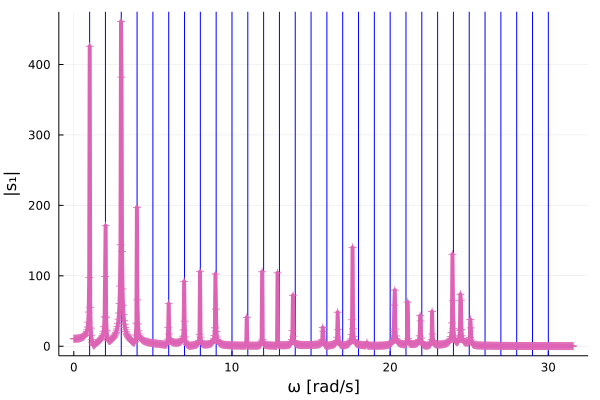

In [19]:
using Plots

plt = plot(xlabel="ω [rad/s]", ylabel="|s₁|", legend=false)

for i = 1:30
    vline!(plt, [i], color=:blue)
end

plot!(plt, ω, abs.(s1), linewidth=4, marker=:cross)

display(plt)

A few observations:
 - Notice that we do not see peaks at $\omega=5,10,15,20,\dots$. The reason is that we sampled $s_1(t)$ around $x=a/5$. Recall the eigenfunction $f_m(x) = \sin \left(\frac{m x}{a}\right)$. Clearly, we have $f_5(a/5)=0$ so that we eigenmode is zero at this point. 𝑇ℎ𝑒𝑟𝑒𝑎𝑠𝑜𝑛𝑖𝑠𝑡ℎ𝑎𝑡𝑤𝑒𝑠𝑎𝑚𝑝𝑙𝑒𝑑
 - The righer resonance frequencies are shifted from the real resonance freqencies. The reason mesh resolution is not capturing the higher oscillating modes well enough.

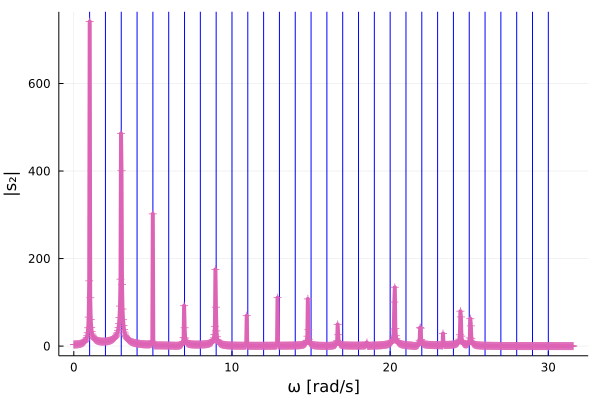

In [20]:
plt = plot(xlabel="ω [rad/s]", ylabel="|s₂|", legend=false, marker=:cross)

for i = 1:30
    vline!(plt, [i], color=:blue)
end

plot!(plt, ω, abs.(s2), linewidth=4, marker=:cross)

display(plt)

Note that due to sampling at $f_5(a/2)=0$ we miss the odd modes.

**Take home message**: Sample at a couple of random sampling points as there is a chance that you sample a point where the oscillating mode is zero.

# What is the effect of the simulation time? 

While we can expect convergence for $t \rightarrow \infty$, there are better and worse simulation times.

For non-canonical problems, we do not know apriori. But in this case, we do.

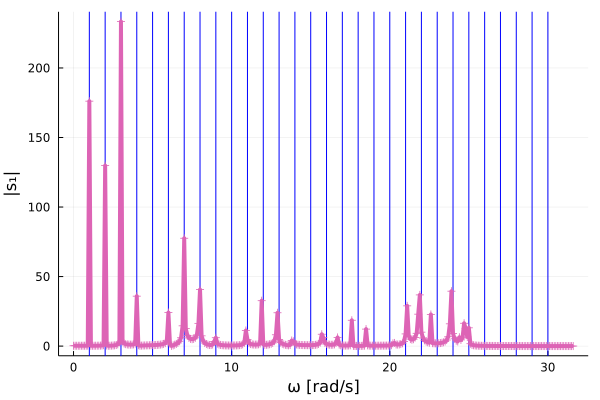

In [21]:
# Recall, with a = π, the wave period of the lowest order mode is 2π
ω, s1, s2, t, sign1, sign2 = Wave1D(Float64(π), 20*π, 30) # Roughly first five modes are sharp, then numerical dispersion kicks in

plt = plot(xlabel="ω [rad/s]", ylabel="|s₁|", legend=false)

for i = 1:30
    vline!(plt, [i], color=:blue)
end

plot!(plt, ω, abs.(s1), linewidth=4, marker=:cross)

display(plt)

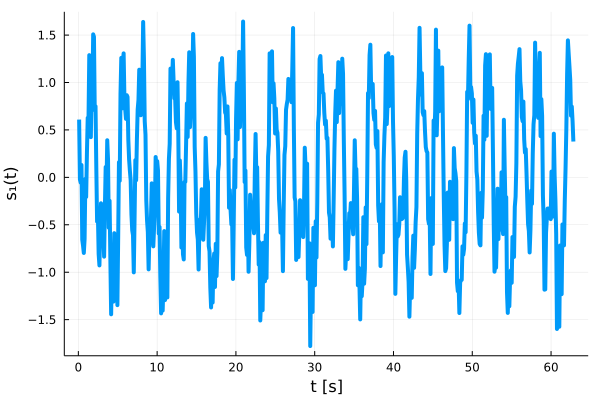

In [22]:
plot(t, sign1,  xlabel="t [s]", ylabel="s₁(t)", legend=false, linewidth=4)

**Observation:** The wave period of the lowest order mode is $2 \pi$. Any integer multiple of this will make the modes appear as sine functions to the FFT, which continues them periodically. This allows to retrieve the frequencies exactly (of course, for higher modes, numerical dispersion kicks in).

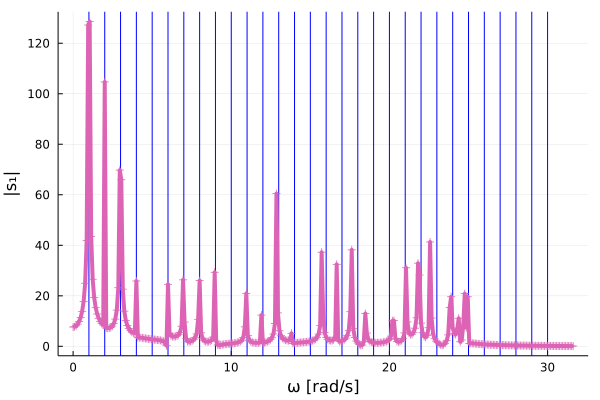

In [23]:
ω, s1, s2, t, sign1, sign2 = Wave1D(Float64(π), 21*π, 30) # Odd ones are broadend

plt = plot(xlabel="ω [rad/s]", ylabel="|s₁|", legend=false)

for i = 1:30
    vline!(plt, [i], color=:blue)
end

plot!(plt, ω, abs.(s1), linewidth=4, marker=:cross)

display(plt)

For half-integer multiples, the odd modes (i.e., $m=1,3,\dots$) will not resemble a sine function. In fact, their first derivative has a jump. This leads to a broadening of the spectrum.

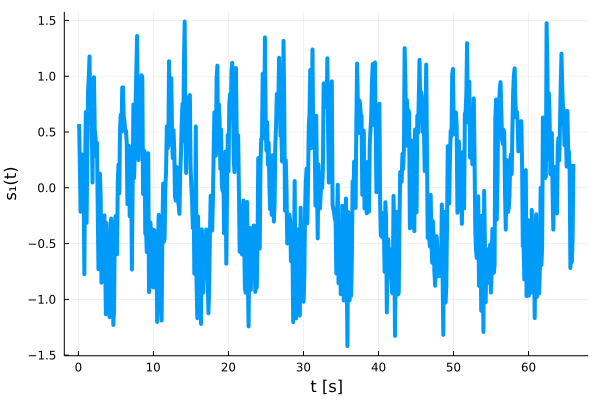

In [24]:
plot(t, sign1,  xlabel="t [s]", ylabel="s₁(t)", legend=false, linewidth=4)

**Observation:** If the time interval is not an integer number of wave periods, either the signal or its time derivative will have a jump at the end of the time window, and this broadens the Fourier spectrum of a sinusoidal signal.

**How can we fix this?** Simulate for a longer time...

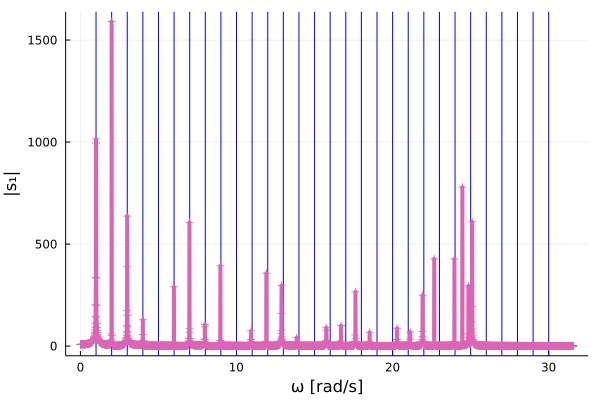

In [25]:
ω, s1, s2, t, sign1, sign2 = Wave1D(Float64(π), 201*π, 30) # Odd ones are broadend

plt = plot(xlabel="ω [rad/s]", ylabel="|s₁|", legend=false)

for i = 1:30
    vline!(plt, [i], color=:blue)
end

plot!(plt, ω, abs.(s1), linewidth=4, marker=:cross)

display(plt)